# Toy M&V Workflow for Building Tune-Up Savings

This notebook is a small public-data analogue of a Measurement & Verification workflow for building tune-up programs.

The goal is not to claim causal savings from public benchmarking data. Instead, the goal is to demonstrate the analytical structure:

1. Select a relevant building cohort.
2. Define pre- and post-periods.
3. Compare weather-normalized energy use.
4. Flag buildings with possible savings or increases.
5. Discuss limitations and what internal data would improve the analysis.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Create project folder
python

In [2]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/sabamv")
DATA_DIR = PROJECT_DIR / "data"
FIG_DIR = PROJECT_DIR / "figures"
OUT_DIR = PROJECT_DIR / "outputs"

for d in [PROJECT_DIR, DATA_DIR, FIG_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)

Project folder: /content/drive/MyDrive/sabamv


Imports and plotting style

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

Download Seattle benchmarking data

In [4]:
DATA_URL = "https://data.seattle.gov/resource/teqw-tu6e.csv?$limit=50000"
RAW_PATH = DATA_DIR / "seattle_building_energy_benchmarking_2015_present.csv"

df_raw = pd.read_csv(DATA_URL)
df_raw.to_csv(RAW_PATH, index=False)

print("Saved raw data to:", RAW_PATH)
print("Shape:", df_raw.shape)
df_raw.head()

/tmp/ipykernel_4112/3770807722.py:4: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(DATA_URL)


Saved raw data to: /content/drive/MyDrive/sabamv/data/seattle_building_energy_benchmarking_2015_present.csv
Shape: (34699, 46)


,osebuildingid,datayear,buildingname,buildingtype,taxparcelidentificationnumber,address,city,state,zipcode,latitude,longitude,neighborhood,councildistrictcode,yearbuilt,numberoffloors,numberofbuildings,propertygfatotal,propertygfabuildings,propertygfaparking,selfreportgfatotal,selfreportgfabuildings,selfreportparking,energystarscore,siteeuiwn_kbtu_sf,siteeui_kbtu_sf,siteenergyuse_kbtu,siteenergyusewn_kbtu,sourceeuiwn_kbtu_sf,sourceeui_kbtu_sf,epapropertytype,largestpropertyusetype,largestpropertyusetypegfa,secondlargestpropertyusetype,secondlargestpropertyuse,thirdlargestpropertyusetype,thirdlargestpropertyusetypegfa,electricity_kwh,steamuse_kbtu,naturalgas_therms,compliancestatus,complianceissue,electricity_kbtu,naturalgas_kbtu,totalghgemissions,ghgemissionsintensity,demolished
0,1,2024,MAYFLOWER PARK HOTEL,NonResidential,659000030,405 OLIVE WAY,SEATTLE,WA,98101,47.61220,-122.33799,DOWNTOWN,7,1927,12,1.0,88434,88434,0,115387,115387,0,59.0,62.200001,61.700001,7113958.0,7172158.0,122.900002,121.400002,Hotel,Hotel,115387.0,NaN,NaN,NaN,NaN,1045040.0,1949686.0,15986.0,Not Compliant,Default Data,3565676.0,1598590.0,263.3,2.98,False
1,2,2024,PARAMOUNT HOTEL,NonResidential,659000220,724 PINE ST,SEATTLE,WA,98101,47.61307,-122.33361,DOWNTOWN,7,1996,11,1.0,103566,88502,15064,103566,88502,15064,85.0,71.900002,71.500000,6330664.0,6362478.0,128.699997,128.300003,Hotel,Hotel,88502.0,Parking,15064.0,NaN,NaN,787838.0,NaN,36426.0,Compliant,No Issue,2688104.0,3642560.0,208.6,2.36,False
2,3,2024,WESTIN HOTEL (Parent Building),NonResidential,659000475,1900 5TH AVE,SEATTLE,WA,98101,47.61367,-122.33822,DOWNTOWN,7,1969,41,3.0,956110,759392,196718,947059,827566,119493,71.0,82.000000,81.699997,67613264.0,67852608.0,171.800003,171.500000,Hotel,Hotel,827566.0,Parking,117783.0,Swimming Pool,NaN,11279080.0,23256386.0,58726.0,Compliant,No Issue,38484221.0,5872650.0,2418.2,3.18,False
3,5,2024,HOTEL MAX,NonResidential,659000640,620 STEWART ST,SEATTLE,WA,98101,47.61412,-122.33664,DOWNTOWN,7,1926,10,1.0,61320,61320,0,61320,61320,0,50.0,87.199997,86.000000,5273981.0,5346375.0,174.699997,171.399994,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,796976.0,1389935.0,11648.0,Compliant,No Issue,2719282.0,1164760.0,190.1,3.10,False
4,8,2024,WARWICK SEATTLE HOTEL,NonResidential,659000970,401 LENORA ST,SEATTLE,WA,98121,47.61395,-122.34087,DOWNTOWN,7,1980,18,1.0,175580,113580,62000,203942,123445,80497,87.0,97.599998,97.099998,11983959.0,12042731.0,167.600006,167.199997,Hotel,Hotel,123445.0,Parking,68009.0,Swimming Pool,NaN,1349025.0,NaN,73811.0,Compliant,No Issue,4602873.0,7381080.0,417.9,3.68,False


Inspect columns

In [5]:
print("Columns:")
for c in df_raw.columns:
    print("-", c)

Columns:
- osebuildingid
- datayear
- buildingname
- buildingtype
- taxparcelidentificationnumber
- address
- city
- state
- zipcode
- latitude
- longitude
- neighborhood
- councildistrictcode
- yearbuilt
- numberoffloors
- numberofbuildings
- propertygfatotal
- propertygfabuildings
- propertygfaparking
- selfreportgfatotal
- selfreportgfabuildings
- selfreportparking
- energystarscore
- siteeuiwn_kbtu_sf
- siteeui_kbtu_sf
- siteenergyuse_kbtu
- siteenergyusewn_kbtu
- sourceeuiwn_kbtu_sf
- sourceeui_kbtu_sf
- epapropertytype
- largestpropertyusetype
- largestpropertyusetypegfa
- secondlargestpropertyusetype
- secondlargestpropertyuse
- thirdlargestpropertyusetype
- thirdlargestpropertyusetypegfa
- electricity_kwh
- steamuse_kbtu
- naturalgas_therms
- compliancestatus
- complianceissue
- electricity_kbtu
- naturalgas_kbtu
- totalghgemissions
- ghgemissionsintensity
- demolished


Clean column types

In [6]:
df = df_raw.copy()

# Standardize column names just in case
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

numeric_cols = [
    "datayear",
    "osebuildingid",
    "yearbuilt",
    "numberoffloors",
    "numberofbuildings",
    "propertygfatotal",
    "propertygfabuildings",
    "propertygfaparking",
    "energystarscore",
    "siteeuiwn_kbtu_sf",
    "siteeui_kbtu_sf",
    "siteenergyuse_kbtu",
    "siteenergyusewn_kbtu",
    "sourceeuiwn_kbtu_sf",
    "sourceeui_kbtu_sf",
    "electricity_kwh",
    "steamuse_kbtu",
    "naturalgas_therms",
    "electricity_kbtu",
    "naturalgas_kbtu",
    "totalghgemissions",
    "ghgemissionsintensity",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove demolished buildings if the column exists
if "demolished" in df.columns:
    df = df[df["demolished"].astype(str).str.lower().isin(["false", "0", "nan"])]

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (34370, 46)


,osebuildingid,datayear,buildingname,buildingtype,taxparcelidentificationnumber,address,city,state,zipcode,latitude,longitude,neighborhood,councildistrictcode,yearbuilt,numberoffloors,numberofbuildings,propertygfatotal,propertygfabuildings,propertygfaparking,selfreportgfatotal,selfreportgfabuildings,selfreportparking,energystarscore,siteeuiwn_kbtu_sf,siteeui_kbtu_sf,siteenergyuse_kbtu,siteenergyusewn_kbtu,sourceeuiwn_kbtu_sf,sourceeui_kbtu_sf,epapropertytype,largestpropertyusetype,largestpropertyusetypegfa,secondlargestpropertyusetype,secondlargestpropertyuse,thirdlargestpropertyusetype,thirdlargestpropertyusetypegfa,electricity_kwh,steamuse_kbtu,naturalgas_therms,compliancestatus,complianceissue,electricity_kbtu,naturalgas_kbtu,totalghgemissions,ghgemissionsintensity,demolished
0,1,2024,MAYFLOWER PARK HOTEL,NonResidential,659000030,405 OLIVE WAY,SEATTLE,WA,98101,47.61220,-122.33799,DOWNTOWN,7,1927,12,1.0,88434,88434,0,115387,115387,0,59.0,62.200001,61.700001,7113958.0,7172158.0,122.900002,121.400002,Hotel,Hotel,115387.0,NaN,NaN,NaN,NaN,1045040.0,1949686.0,15986.0,Not Compliant,Default Data,3565676.0,1598590.0,263.3,2.98,False
1,2,2024,PARAMOUNT HOTEL,NonResidential,659000220,724 PINE ST,SEATTLE,WA,98101,47.61307,-122.33361,DOWNTOWN,7,1996,11,1.0,103566,88502,15064,103566,88502,15064,85.0,71.900002,71.500000,6330664.0,6362478.0,128.699997,128.300003,Hotel,Hotel,88502.0,Parking,15064.0,NaN,NaN,787838.0,NaN,36426.0,Compliant,No Issue,2688104.0,3642560.0,208.6,2.36,False
2,3,2024,WESTIN HOTEL (Parent Building),NonResidential,659000475,1900 5TH AVE,SEATTLE,WA,98101,47.61367,-122.33822,DOWNTOWN,7,1969,41,3.0,956110,759392,196718,947059,827566,119493,71.0,82.000000,81.699997,67613264.0,67852608.0,171.800003,171.500000,Hotel,Hotel,827566.0,Parking,117783.0,Swimming Pool,NaN,11279080.0,23256386.0,58726.0,Compliant,No Issue,38484221.0,5872650.0,2418.2,3.18,False
3,5,2024,HOTEL MAX,NonResidential,659000640,620 STEWART ST,SEATTLE,WA,98101,47.61412,-122.33664,DOWNTOWN,7,1926,10,1.0,61320,61320,0,61320,61320,0,50.0,87.199997,86.000000,5273981.0,5346375.0,174.699997,171.399994,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,796976.0,1389935.0,11648.0,Compliant,No Issue,2719282.0,1164760.0,190.1,3.10,False
4,8,2024,WARWICK SEATTLE HOTEL,NonResidential,659000970,401 LENORA ST,SEATTLE,WA,98121,47.61395,-122.34087,DOWNTOWN,7,1980,18,1.0,175580,113580,62000,203942,123445,80497,87.0,97.599998,97.099998,11983959.0,12042731.0,167.600006,167.199997,Hotel,Hotel,123445.0,Parking,68009.0,Swimming Pool,NaN,1349025.0,NaN,73811.0,Compliant,No Issue,4602873.0,7381080.0,417.9,3.68,False


Quick data quality profile

In [7]:
profile_cols = [
    "datayear",
    "osebuildingid",
    "buildingtype",
    "epapropertytype",
    "largestpropertyusetype",
    "propertygfatotal",
    "siteeuiwn_kbtu_sf",
    "siteeui_kbtu_sf",
    "siteenergyuse_kbtu",
    "totalghgemissions",
]

profile_cols = [c for c in profile_cols if c in df.columns]

summary = pd.DataFrame({
    "missing_count": df[profile_cols].isna().sum(),
    "missing_pct": 100 * df[profile_cols].isna().mean(),
    "n_unique": df[profile_cols].nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

summary

,missing_count,missing_pct,n_unique
siteeuiwn_kbtu_sf,1631,4.745418,2447
siteeui_kbtu_sf,1265,3.680535,2445
siteenergyuse_kbtu,1259,3.663078,32998
totalghgemissions,851,2.475997,4832
largestpropertyusetype,18,0.052371,69
epapropertytype,18,0.052371,71
osebuildingid,0,0.000000,3749
datayear,0,0.000000,10
propertygfatotal,0,0.000000,3566
buildingtype,0,0.000000,8


Explore building types

In [8]:
type_col = "largestpropertyusetype"

type_counts = (
    df[type_col]
    .fillna("Unknown")
    .value_counts()
    .head(25)
    .reset_index()
)

type_counts.columns = ["building_use_type", "records"]
type_counts

,building_use_type,records
0,Multifamily Housing,18383
1,Office,4920
2,Non-Refrigerated Warehouse,1598
3,K-12 School,1336
4,Retail Store,789
5,Hotel,786
6,Worship Facility,652
7,Other,630
8,Distribution Center,468
9,Medical Office,446


Plot common building types

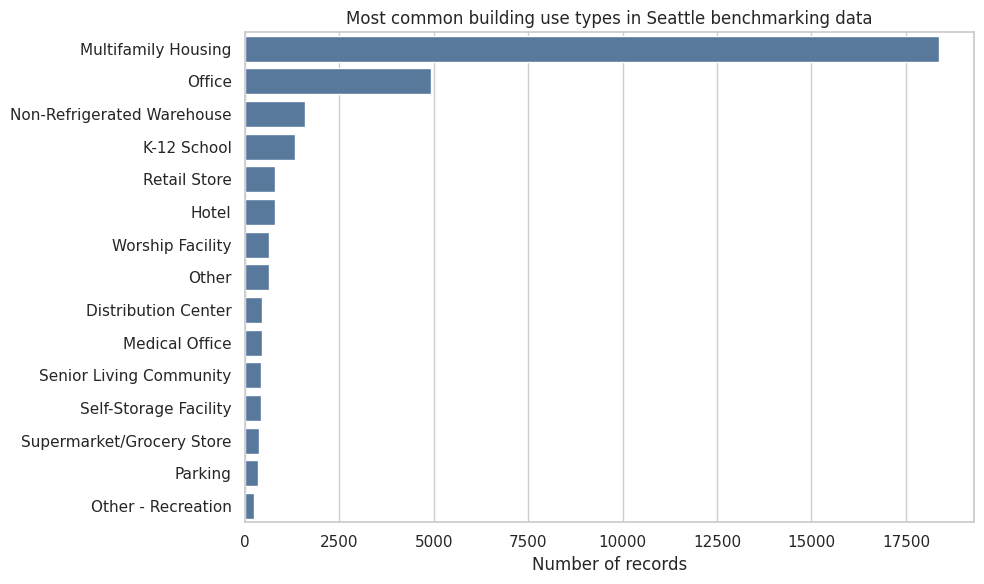

Saved: /content/drive/MyDrive/sabamv/figures/common_building_types.png


In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=type_counts.head(15),
    y="building_use_type",
    x="records",
    color="#4C78A8"
)
plt.title("Most common building use types in Seattle benchmarking data")
plt.xlabel("Number of records")
plt.ylabel("")
plt.tight_layout()

fig_path = FIG_DIR / "common_building_types.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

Define toy M&V cohort

In [10]:
# This mirrors the report idea: larger non-residential buildings with enough data.
# You can change "Office" to "Hotel", "K-12 School", "Medical Office", etc.

TARGET_USE = "Office"
MIN_GFA = 50_000

cohort = df.copy()

cohort = cohort[
    cohort["largestpropertyusetype"].astype(str).str.contains(TARGET_USE, case=False, na=False)
]

cohort = cohort[
    cohort["propertygfatotal"].fillna(0) >= MIN_GFA
]

# Keep reasonable EUI values to avoid obvious data errors
cohort = cohort[
    cohort["siteeuiwn_kbtu_sf"].between(1, 1000)
]

print("Cohort shape:", cohort.shape)
print("Unique buildings:", cohort["osebuildingid"].nunique())
cohort[["osebuildingid", "buildingname", "datayear", "largestpropertyusetype", "propertygfatotal", "siteeuiwn_kbtu_sf"]].head()

Cohort shape: (3265, 46)
Unique buildings: 399


,osebuildingid,buildingname,datayear,largestpropertyusetype,propertygfatotal,siteeuiwn_kbtu_sf
30,38,GOOD SHEPHERD CENTER,2024,Office,87262,53.000000
33,43,BOEING PLANT 2 ISAL (BLDG 2-122)-North Boeing...,2024,Office,2026324,252.800003
36,53,EL CENTRO DE LA RAZA,2024,Office,52554,48.500000
40,57,5TH & PINE,2024,Office,88717,30.200001
42,59,GIBRALTAR TOWER,2024,Office,59400,26.500000


## Toy pre/post design

The attached report compares pre- and post-tune-up energy use, including weather-normalized results when possible.

For this public-data toy version, I use:

- **Pre period:** 2017
- **Post period:** 2019
- **Main metric:** weather-normalized site EUI, in kBtu/sf
- **Savings definition:** positive savings means post-period EUI is lower than pre-period EUI

Important limitation: the public benchmarking dataset does not include actual tune-up action dates, action-level persistence checks, or monthly utility data. Therefore, this notebook demonstrates the M&V workflow, not a causal estimate.

Compute 2017 vs 2019 pre/post change

In [11]:
PRE_YEAR = 2017
POST_YEAR = 2019
METRIC = "siteeuiwn_kbtu_sf"

needed = [
    "osebuildingid",
    "buildingname",
    "address",
    "datayear",
    "largestpropertyusetype",
    "propertygfatotal",
    METRIC,
    "siteeui_kbtu_sf",
    "siteenergyuse_kbtu",
    "totalghgemissions",
    "energystarscore",
]

needed = [c for c in needed if c in cohort.columns]

wide = cohort[needed].copy()

pre = wide[wide["datayear"] == PRE_YEAR].set_index("osebuildingid")
post = wide[wide["datayear"] == POST_YEAR].set_index("osebuildingid")

common_ids = pre.index.intersection(post.index)

mv = pd.DataFrame({
    "buildingname": pre.loc[common_ids, "buildingname"],
    "address": pre.loc[common_ids, "address"],
    "largestpropertyusetype": pre.loc[common_ids, "largestpropertyusetype"],
    "propertygfatotal": pre.loc[common_ids, "propertygfatotal"],
    f"pre_{METRIC}": pre.loc[common_ids, METRIC],
    f"post_{METRIC}": post.loc[common_ids, METRIC],
})

mv["absolute_change_eui"] = mv[f"post_{METRIC}"] - mv[f"pre_{METRIC}"]
mv["percent_change_eui"] = 100 * mv["absolute_change_eui"] / mv[f"pre_{METRIC}"]
mv["toy_savings_percent"] = -mv["percent_change_eui"]

mv = mv.replace([np.inf, -np.inf], np.nan).dropna(subset=["toy_savings_percent"])

print("Buildings with both pre and post data:", len(mv))
mv.sort_values("toy_savings_percent", ascending=False).head(10)

Buildings with both pre and post data: 297


,buildingname,address,largestpropertyusetype,propertygfatotal,pre_siteeuiwn_kbtu_sf,post_siteeuiwn_kbtu_sf,absolute_change_eui,percent_change_eui,toy_savings_percent
osebuildingid,,,,,,,,,
803,200 SW MICHIGAN,200 SW MICHIGAN ST,Office,85126,404.299988,23.000000,-381.299988,-94.311155,94.311155
339,BRODERICK BUILDING,615 2ND AVE,Office,89550,52.099998,7.100000,-44.999999,-86.372361,86.372361
340,PIONEER BUILDING,600 1ST AVE,Office,89355,46.099998,12.400000,-33.699999,-73.101952,73.101952
1560,TALLMAN BUILDING,5350 TALLMAN AVE NW,Medical Office,92477,89.000000,25.100000,-63.900000,-71.797752,71.797752
706,333 ELLIOTT,333 ELLIOTT AVE W,Office,183964,110.000000,33.599998,-76.400002,-69.454547,69.454547
703,ELLIOTT WEST BLDG 3 - CELL THEREPEUTICS/ADMIN....,501 ELLIOTT AVE W,Office,165111,261.799988,98.400002,-163.399986,-62.414054,62.414054
858,JAMES TOWER (PROVIDENCE MEDICAL CENTER),528 17TH AVE,Medical Office,320946,146.199997,69.199997,-77.000000,-52.667580,52.667580
443,ELLIOTT BAY OFFICE PARK,300 ELLIOTT AVE W,Office,275734,34.099998,18.200001,-15.899998,-46.627561,46.627561
492,QUEEN ANNE PLAZA,201 QUEEN ANNE AVE N,Office,86995,50.400002,27.000000,-23.400002,-46.428573,46.428573


Summary statistics

In [12]:
summary_stats = mv["toy_savings_percent"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
summary_stats

,toy_savings_percent
count,297.000000
mean,3.300915
std,23.377760
min,-120.434786
5%,-29.420498
25%,-5.392159
50%,4.207117
75%,12.921885
95%,38.826823
max,94.311155


Plot savings distribution

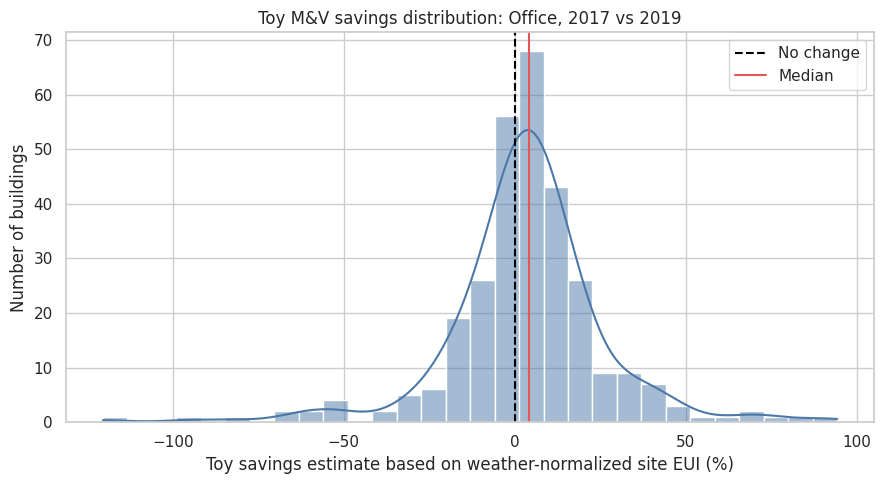

Saved: /content/drive/MyDrive/sabamv/figures/toy_savings_distribution.png


In [13]:
plt.figure(figsize=(9, 5))
sns.histplot(mv["toy_savings_percent"], bins=30, kde=True, color="#4C78A8")
plt.axvline(0, color="black", linestyle="--", label="No change")
plt.axvline(mv["toy_savings_percent"].median(), color="#E45756", linestyle="-", label="Median")
plt.title(f"Toy M&V savings distribution: {TARGET_USE}, {PRE_YEAR} vs {POST_YEAR}")
plt.xlabel("Toy savings estimate based on weather-normalized site EUI (%)")
plt.ylabel("Number of buildings")
plt.legend()
plt.tight_layout()

fig_path = FIG_DIR / "toy_savings_distribution.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

Select a 10-building toy sample

In [14]:
# Choose a balanced sample:
# - 4 buildings with apparent savings
# - 3 buildings near no change
# - 3 buildings with apparent increases
# This is more honest than only showing the "best" buildings.

savers = mv[mv["toy_savings_percent"] > 5].sort_values("toy_savings_percent", ascending=False).head(4)
neutral = mv[mv["toy_savings_percent"].between(-5, 5)].iloc[:3]
increasers = mv[mv["toy_savings_percent"] < -5].sort_values("toy_savings_percent", ascending=True).head(3)

sample10 = pd.concat([savers, neutral, increasers]).copy()

sample10 = sample10.reset_index().rename(columns={"osebuildingid": "OSE Building ID"})

sample10_display = sample10[
    [
        "OSE Building ID",
        "buildingname",
        "address",
        "largestpropertyusetype",
        "propertygfatotal",
        f"pre_{METRIC}",
        f"post_{METRIC}",
        "absolute_change_eui",
        "toy_savings_percent",
    ]
].copy()

sample10_display.columns = [
    "OSE Building ID",
    "Building Name",
    "Address",
    "Use Type",
    "Gross Floor Area",
    f"{PRE_YEAR} Weather-Normalized Site EUI",
    f"{POST_YEAR} Weather-Normalized Site EUI",
    "Absolute EUI Change",
    "Toy Savings %",
]

sample10_display.round(2)

,OSE Building ID,Building Name,Address,Use Type,Gross Floor Area,2017 Weather-Normalized Site EUI,2019 Weather-Normalized Site EUI,Absolute EUI Change,Toy Savings %
0,803,200 SW MICHIGAN,200 SW MICHIGAN ST,Office,85126,404.3,23.0,-381.3,94.31
1,339,BRODERICK BUILDING,615 2ND AVE,Office,89550,52.1,7.1,-45.0,86.37
2,340,PIONEER BUILDING,600 1ST AVE,Office,89355,46.1,12.4,-33.7,73.10
3,1560,TALLMAN BUILDING,5350 TALLMAN AVE NW,Medical Office,92477,89.0,25.1,-63.9,71.80
4,43,BOEING PLANT 2 ISAL (BLDG 2-122)-North Boeing...,1135 S WEBSTER ST,Office,2026324,286.5,279.5,-7.0,2.44
5,82,WA DEPT OF SOCIAL & HEALTH SERVICES (DSHS),1700 E CHERRY ST,Office,54984,64.5,66.1,1.6,-2.48
6,96,BLOODWORKS NW CENTRAL SEATTLE,921 TERRY AVE,Medical Office,121099,193.9,187.8,-6.1,3.15
7,549,400 MERCER STREET OFFICE BUILDING,400 MERCER ST,Office,80019,23.0,50.7,27.7,-120.43
8,49867,HOME PLATE CENTER BLDG B,1521 1ST AVE S,Office,333714,34.6,67.5,32.9,-95.09
9,616,COURT IN THE SQUARE (Goldsmith & Northcoast),401 2ND AVE S,Office,160580,28.0,50.6,22.6,-80.71


 Plot sample buildings

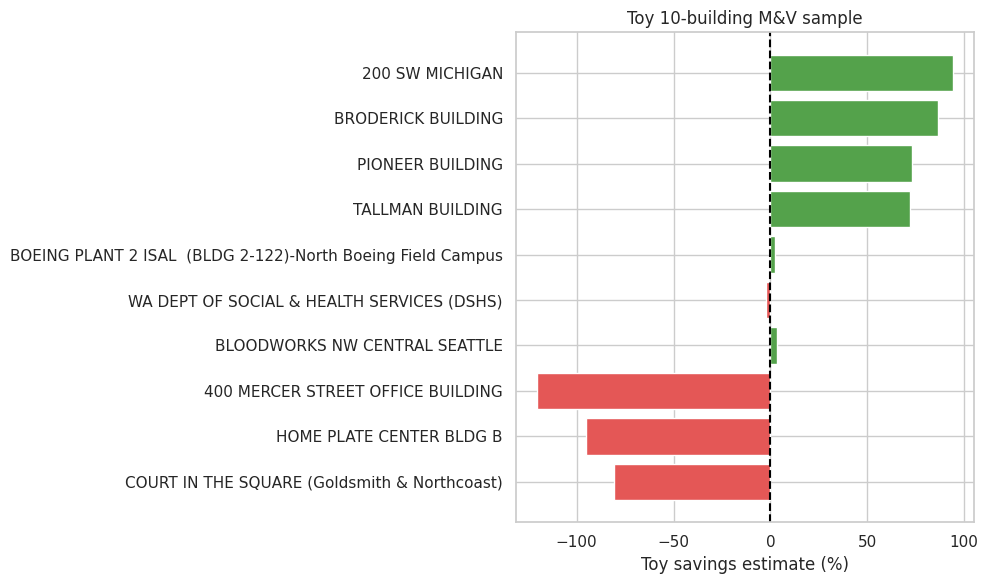

Saved: /content/drive/MyDrive/sabamv/figures/toy_sample10_savings.png


In [15]:
plot_df = sample10_display.copy()
plot_df["Building Label"] = plot_df["Building Name"].fillna("Building " + plot_df["OSE Building ID"].astype(str))

plt.figure(figsize=(10, 6))
colors = np.where(plot_df["Toy Savings %"] >= 0, "#54A24B", "#E45756")

plt.barh(plot_df["Building Label"], plot_df["Toy Savings %"], color=colors)
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Toy savings estimate (%)")
plt.title("Toy 10-building M&V sample")
plt.gca().invert_yaxis()
plt.tight_layout()

fig_path = FIG_DIR / "toy_sample10_savings.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

Save results to Drive
python

In [16]:
MV_PATH = OUT_DIR / "toy_mv_all_buildings.csv"
SAMPLE_PATH = OUT_DIR / "toy_mv_sample10.csv"

mv.reset_index().to_csv(MV_PATH, index=False)
sample10_display.to_csv(SAMPLE_PATH, index=False)

print("Saved full M&V table:", MV_PATH)
print("Saved sample 10 table:", SAMPLE_PATH)

Saved full M&V table: /content/drive/MyDrive/sabamv/outputs/toy_mv_all_buildings.csv
Saved sample 10 table: /content/drive/MyDrive/sabamv/outputs/toy_mv_sample10.csv


Toy M&V summary

Dataset:
- City of Seattle public building energy benchmarking data.
- Cohort: Office buildings with gross floor area >= 50,000 sq ft.
- Pre period: 2017
- Post period: 2019
- Metric: weather-normalized site EUI, kBtu/sf.

Results:
- Buildings with both pre and post data: 297
- Median toy savings estimate: 4.21%
- Share of buildings with lower post-period EUI: 61.3%
- Largest apparent savings: 94.31%
- Largest apparent increase: -120.43%

Interpretation:
This is a public-data demonstration of the M&V workflow, not a causal estimate.
The analysis shows how I would structure a pre/post comparison, use weather-normalized energy metrics,
identify buildings worth deeper review, and communicate uncertainty.

What would improve this with internal project data:
1. Monthly electric and gas utility data.
2. Exact tune-up assessment and implementation dates.
3. Action-level categories such as HVAC schedules, setpoints, controls, lighting, and envelope.
4. Persistence verification from site visits, BAS trend data, or logger data.
5. Occupancy and operating-hours changes.

## Limitations

This notebook is intentionally framed as a toy public-data M&V workflow.

The main limitations are:

1. **No verified intervention date:** The public dataset does not identify when a specific building completed a tune-up.
2. **Annual data only:** The report-style M&V workflow benefits from monthly utility data, while this notebook uses annual benchmarking records.
3. **No action-level persistence data:** The public data does not show whether HVAC schedules, setpoints, dampers, thermostats, or lighting controls were corrected and remained corrected.
4. **Potential confounding:** Occupancy, operating hours, tenants, equipment changes, and COVID-era disruptions can affect energy use.
5. **Not causal:** A lower post-period EUI should be interpreted as a signal for follow-up, not proof of savings.

If I had access to internal project data, I would extend this by fitting building-level baseline models using monthly energy and weather data, then comparing observed post-period use against a weather-normalized counterfactual.

Compare multiple building types

In [17]:
target_types = ["Office", "Hotel", "K-12 School", "Medical Office", "College", "Warehouse"]

multi_results = []

for t in target_types:
    temp = df.copy()
    temp = temp[temp["largestpropertyusetype"].astype(str).str.contains(t, case=False, na=False)]
    temp = temp[temp["propertygfatotal"].fillna(0) >= MIN_GFA]
    temp = temp[temp[METRIC].between(1, 1000)]

    pre_t = temp[temp["datayear"] == PRE_YEAR].set_index("osebuildingid")
    post_t = temp[temp["datayear"] == POST_YEAR].set_index("osebuildingid")
    ids = pre_t.index.intersection(post_t.index)

    if len(ids) == 0:
        continue

    tmp = pd.DataFrame({
        "use_type_query": t,
        "pre_eui": pre_t.loc[ids, METRIC],
        "post_eui": post_t.loc[ids, METRIC],
    })
    tmp["toy_savings_percent"] = -100 * (tmp["post_eui"] - tmp["pre_eui"]) / tmp["pre_eui"]
    multi_results.append(tmp.reset_index())

multi = pd.concat(multi_results, ignore_index=True)

multi_summary = (
    multi.groupby("use_type_query")["toy_savings_percent"]
    .agg(["count", "median", "mean"])
    .reset_index()
    .sort_values("median", ascending=False)
)

multi_summary.round(2)

,use_type_query,count,median,mean
0,College,10,5.70,-0.14
5,Warehouse,46,5.58,-16.01
4,Office,297,4.21,3.30
1,Hotel,56,3.51,4.20
3,Medical Office,22,3.34,6.91
2,K-12 School,77,2.03,1.98


Plot multiple building types

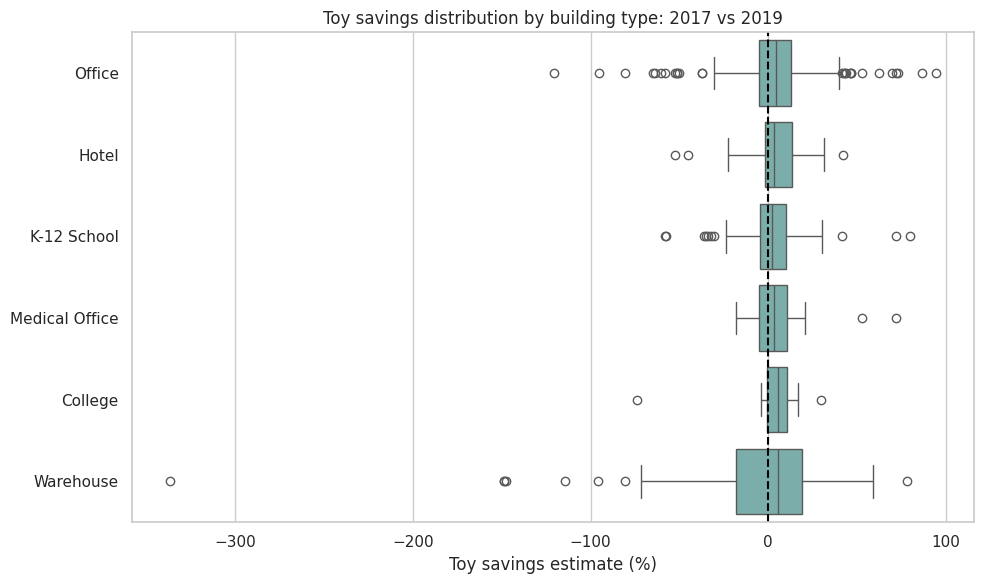

Saved: /content/drive/MyDrive/sabamv/figures/toy_savings_by_building_type.png


In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=multi,
    y="use_type_query",
    x="toy_savings_percent",
    color="#72B7B2"
)
plt.axvline(0, color="black", linestyle="--")
plt.title(f"Toy savings distribution by building type: {PRE_YEAR} vs {POST_YEAR}")
plt.xlabel("Toy savings estimate (%)")
plt.ylabel("")
plt.tight_layout()

fig_path = FIG_DIR / "toy_savings_by_building_type.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)